In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
print("Imports Completed")

Imports Completed


In [73]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [74]:
X = df[['displacement']]
y = df['mpg']

print("Missing Values in ", X.isnull().sum())
print("Missing values in mpg: ",X.isnull().sum())


Missing Values in  displacement    0
dtype: int64
Missing values in mpg:  displacement    0
dtype: int64


In [75]:
data = df[['displacement', 'mpg']].dropna()

X = data[['displacement']]
y = data['mpg']

print("Feature: ")
print(X.head())

print("\nTarget: ")
print(y.head())

Feature: 
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target: 
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Samples: ", len(X_train))
print("Testing Samples: ", len(X_test))


Training Samples:  318
Testing Samples:  80


In [77]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

In [78]:
print("Linear Regression Results")
mse_linear = mean_squared_error(y_test,y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("MSE: ",mse_linear)
print("R2 Score: ", r2_linear)

Linear Regression Results
MSE:  18.102543998358946
R2 Score:  0.6633114869465595


In [79]:
results = []

polynomial_models = {}

results.append({
    'Model':'Linear Regression',
    'Degree':1,
    'MSE':mse_linear,
    'R-squared':r2_linear
})

for degree in range (2,6):
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()

    poly_model.fit(X_train_poly, y_train)
    y_pred_poly = poly_model.predict(X_test_poly)

    mse = mean_squared_error(y_test,y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)

    results.append({
        'Model':'Polynomial Regression',
        'Degree':degree,
        'MSE':mse,
        'R-squared':r2
    })

    polynomial_models[degree]={
        'poly':poly,
        'model': poly_model
    }


In [80]:
results_df = pd.DataFrame(results)

results_df

,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


<function matplotlib.pyplot.show(close=None, block=None)>

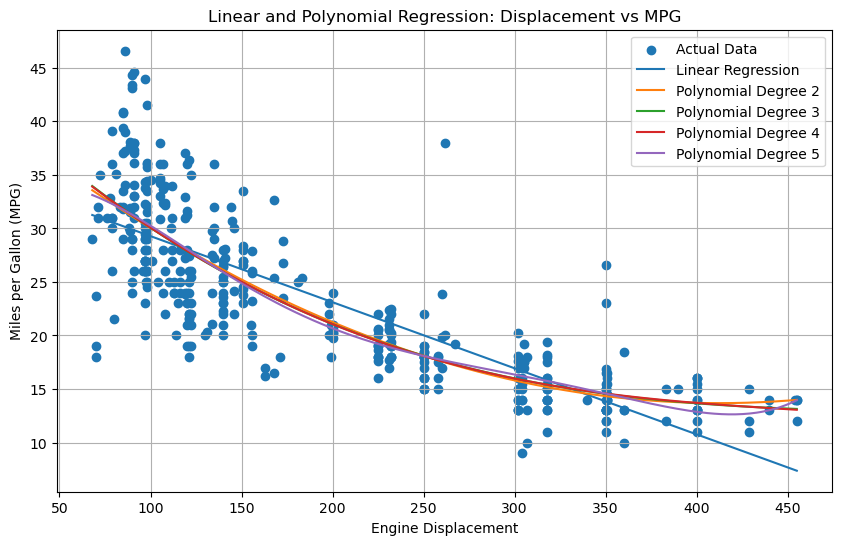

In [81]:
X_plot = pd.DataFrame({
    'displacement':np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300)
})

plt.figure(figsize=(10,6))

plt.scatter(
    X['displacement'],
    y,
    label='Actual Data'
)
y_plot_linear = linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label='Linear Regression'
)

for degree in range(2,6):

    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    X_plot_poly = poly.transform(X_plot)

    y_plot_poly = poly_model.predict(X_plot_poly)

    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        label=f'Polynomial Degree {degree}'
    )

plt.xlabel('Engine Displacement')
plt.ylabel('Miles per Gallon (MPG)')
plt.title('Linear and Polynomial Regression: Displacement vs MPG')

plt.legend()
plt.grid(True)
plt.show

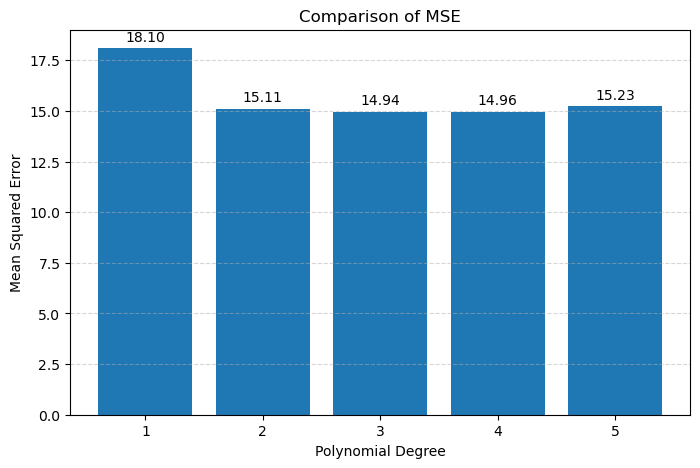

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

plt.bar_label(bars, fmt='%.2f', padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

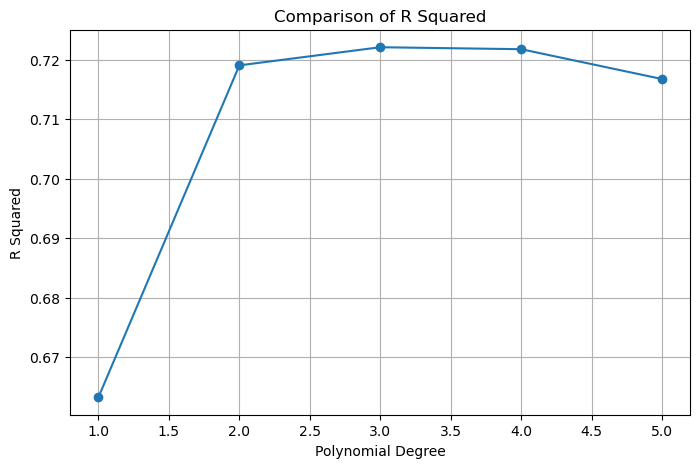

In [83]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R Squared")
plt.title("Comparison of R Squared")
plt.grid(True)
plt.show()